In [1]:
# importing data 
import yfinance as yf 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 

import warnings 
warnings.filterwarnings('ignore')

In [2]:
stock_data = yf.download('AAPL',start='2024-01-01')

[*********************100%***********************]  1 of 1 completed


# Test for weak stationarity 
- Adfuller
- KPSS

# ADfuller--

### **Key Criteria for ADF Test**
1. **Null Hypothesis (H₀):**
   - The time series has a unit root, i.e., it is **non-stationary**.

2. **Alternate Hypothesis (H₁):**
   - The time series does not have a unit root, i.e., it is **stationary**.

---

### **Steps to Check Stationarity**
1. **Compare the p-value to the Significance Level (α):**
   - The p-value is the probability of obtaining test results at least as extreme as the observed results, assuming the null hypothesis is true.
   - Typically, a significance level of **α = 0.05 (5%)** is used.
     - **If p-value < 0.05**: Reject the null hypothesis (H₀). The data is **stationary**.
     - **If p-value ≥ 0.05**: Fail to reject the null hypothesis (H₀). The data is **non-stationary**.

2. **Compare the ADF Statistic to Critical Values:**
   - The ADF statistic is compared against the critical values at different confidence levels (e.g., 1%, 5%, 10%).
     - **If ADF Statistic < Critical Value (at a chosen level):** Reject H₀. The data is **stationary**.
     - **If ADF Statistic > Critical Value:** Fail to reject H₀. The data is **non-stationary**.

3. **Overall Interpretation:**
   - Both the p-value and ADF statistic should be considered together to conclude whether the series is stationary.

---

### **Example**
Let's assume the ADF test returns the following:

- **ADF Statistic**: -3.5  
- **p-value**: 0.02  
- **Critical Values**:  
  - 1%: -3.6  
  - 5%: -2.9  
  - 10%: -2.6  

#### Interpretation:
1. **p-value Check**:  
   - p-value (0.02) < 0.05, so we reject the null hypothesis. The data is stationary.
   
2. **ADF Statistic Check**:  
   - ADF Statistic (-3.5) < Critical Value at 5% (-2.9), so we reject the null hypothesis. The data is stationary.

**Conclusion**: Based on both criteria, the data is stationary.

---

### **Practical Note**
- A stationary series means that its statistical properties, such as mean, variance, and autocorrelation, remain constant over time.  
- If the series is non-stationary, transformations like **differencing**, **log transformation**, or or an example of how to transform non-stationary data!

In [3]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test
adf_test = adfuller(stock_data['Close'])

print('ADF Test Results:')
print(f'ADF Statistics: {round(adf_test[0], 3)}')
print(f'p-value: {round(adf_test[1], 3)}')  # Missing closing parenthesis fixed here
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f'\t{key} : {round(value, 3)}')

ADF Test Results:
ADF Statistics: -1.056
p-value: 0.732
Critical Values:
	1% : -3.455
	5% : -2.873
	10% : -2.573


# Snippit for ADFuller Test

In [4]:
# Perform the Augmented Dickey-Fuller test
adf_test = adfuller(stock_data['Close'])

# Print the ADF Test Results
print('ADF Test Results:')
print(f'ADF Statistic: {round(adf_test[0], 3)}')
print(f'p-value: {round(adf_test[1], 3)}')
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f'\t{key} : {round(value, 3)}')

# Null Hypothesis and Alternate Hypothesis
print("\nHypothesis Testing:")
print("Null Hypothesis (H0): The data has a unit root (non-stationary).")
print("Alternate Hypothesis (H1): The data does not have a unit root (stationary).")

# Determine if the data is stationary or not
alpha = 0.05  # Common significance level
if adf_test[1] < alpha:
    print("\nResult:")
    print(f"p-value ({round(adf_test[1], 3)}) < {alpha}")
    print("We reject the null hypothesis (H0). The data is stationary.")
else:
    print("\nResult:")
    print(f"p-value ({round(adf_test[1], 3)}) >= {alpha}")
    print("We fail to reject the null hypothesis (H0). The data is non-stationary.")

# Optional: Add a check based on the ADF Statistic vs critical values
critical_values_check = all(adf_test[0] < value for value in adf_test[4].values())
if critical_values_check:
    print("\nAdditional Check:")
    print("ADF Statistic is less than all critical values.")
    print


ADF Test Results:
ADF Statistic: -1.056
p-value: 0.732
Critical Values:
	1% : -3.455
	5% : -2.873
	10% : -2.573

Hypothesis Testing:
Null Hypothesis (H0): The data has a unit root (non-stationary).
Alternate Hypothesis (H1): The data does not have a unit root (stationary).

Result:
p-value (0.732) >= 0.05
We fail to reject the null hypothesis (H0). The data is non-stationary.


# KPSS Test 

The **KPSS (Kwiatkowski-Phillips-Schmidt-Shin) test** is also used to determine whether a time series is **stationary** or **non-stationary**, but it differs from the Augmented Dickey-Fuller (ADF) test in its hypotheses and interpretation.

---

### **Key Criteria for KPSS Test**
1. **Null Hypothesis (H₀):**
   - The time series is **stationary**.
   - (Level stationarity if `regression='c'`, trend stationarity if `regression='ct'`).

2. **Alternate Hypothesis (H₁):**
   - The time series is **non-stationary**.

---

### **Steps to Check Stationarity**
1. **Compare the p-value to the Significance Level (α):**
   - The p-value tells the probability of observing the test statistic under the null hypothesis.
   - Typically, a significance level of **α = 0.05 (5%)** is used:
     - **If p-value < 0.05**: Reject the null hypothesis (H₀). The data is **non-stationary**.
     - **If p-value ≥ 0.05**: Fail to reject the null hypothesis (H₀). The data is **stationary**.

2. **Compare the KPSS Statistic to Critical Values:**
   - The KPSS statistic is compared against the critical values at different confidence levels (e.g., 1%, 5%, 10%):
     - **If KPSS Statistic > Critical Value**: Reject the null hypothesis (H₀). The data is **non-stationary**.
     - **If KPSS Statistic ≤ Critical Value**: Fail to reject the null hypothesis (H₀). The data is **stationary**.

3. **Interpretation:**
   - Both the p-value and KPSS statistic should be considered to determine the stationarity of the data.

---

### **Example**
Let’s assume the KPSS test returns the following:

- **KPSS Statistic**: 0.5  
- **p-value**: 0.04  
- **Critical Values**:  
  - 1%: 0.739  
  - 5%: 0.463  
  - 10%: 0.347  

#### Interpretation:
1. **p-value Check**:
   - p-value (0.04) < 0.05, so we reject the null hypothesis. The data is **non-stationary**.
   
2. **KPSS Statistic Check**:
   - KPSS Statistic (0.5) > Critical Value at 5% (0.463), so we reject the null hypothesis. The data is **non-stationary**.

**Conclusion**: Based on both criteria, the data is non-stationary.

---

### **Differences Between ADF and KPSS**
1. **Hypotheses:**
   - ADF: Null hypothesis is **non-stationarity**.
   - KPSS: Null hypothesis is **stationarity**.

2. **Usage Together:**
   - ADF and KPSS tests can complement each other.  
     - If the ADF test rejects H₀ and the KPSS test fails to reject H₀, the data is stationary.
     - If both reject H₀, the data is non-stationary.

---

### **Practical Note**
- The KPSS test is more sensitive to **trend stationarity**, so it’s often used to detect structural breaks or trends in the data.
- If the data is non-stationary, you can apply transformations like **differencing**,know if you’d like an example combining both the ADF and KPSS tests!

In [5]:
from statsmodels.tsa.stattools import kpss 

kpss_test = kpss(stock_data['Close'], regression='ct') # 'c' for constant(Level Stationarity), 'ct' is trend

print('KPSS Test Results:')
print(f'KPSS Statistics : {round(kpss_test[0],2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'{key}: {value}')

KPSS Test Results:
KPSS Statistics : 0.18
p-value: 0.02197913841519421
Critical Values:
10%: 0.119
5%: 0.146
2.5%: 0.176
1%: 0.216


# Snippit for KPSS Test

In [6]:
from statsmodels.tsa.stattools import kpss 

# Perform the KPSS test
kpss_test = kpss(stock_data['Close'], regression='ct')  # 'c' for level stationarity, 'ct' for trend stationarity

# Print the KPSS Test Results
print('KPSS Test Results:')
print(f'KPSS Statistic: {round(kpss_test[0], 2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'\t{key}: {value}')

# Null Hypothesis and Alternate Hypothesis
print("\nHypothesis Testing:")
print("Null Hypothesis (H0): The data is stationary (no unit root).")
print("Alternate Hypothesis (H1): The data is non-stationary (has a unit root).")

# Determine if the data is stationary or not
alpha = 0.05  # Common significance level
if kpss_test[1] < alpha:
    print("\nResult:")
    print(f"p-value ({kpss_test[1]}) < {alpha}")
    print("We reject the null hypothesis (H0). The data is non-stationary.")
else:
    print("\nResult:")
    print(f"p-value ({kpss_test[1]}) >= {alpha}")
    print("We fail to reject the null hypothesis (H0). The data is stationary.")

# Optional: Add a check based on the KPSS Statistic vs critical values
if kpss_test[0] > kpss_test[3]['5%']:
    print("\nAdditional Check:")
    print("KPSS Statistic is greater than the critical value at the 5% level.")
    print("This further supports that the data is non-stationary.")
else:
    print("\nAdditional Check:")
    print("KPSS Statistic is less than or equal to the critical value at the 5% level.")
    print("This further supports that the data is stationary.")


KPSS Test Results:
KPSS Statistic: 0.18
p-value: 0.02197913841519421
Critical Values:
	10%: 0.119
	5%: 0.146
	2.5%: 0.176
	1%: 0.216

Hypothesis Testing:
Null Hypothesis (H0): The data is stationary (no unit root).
Alternate Hypothesis (H1): The data is non-stationary (has a unit root).

Result:
p-value (0.02197913841519421) < 0.05
We reject the null hypothesis (H0). The data is non-stationary.

Additional Check:
KPSS Statistic is greater than the critical value at the 5% level.
This further supports that the data is non-stationary.


## Test for Strict Stationarity 

# K-S Test 

#### Generating synthetic data 

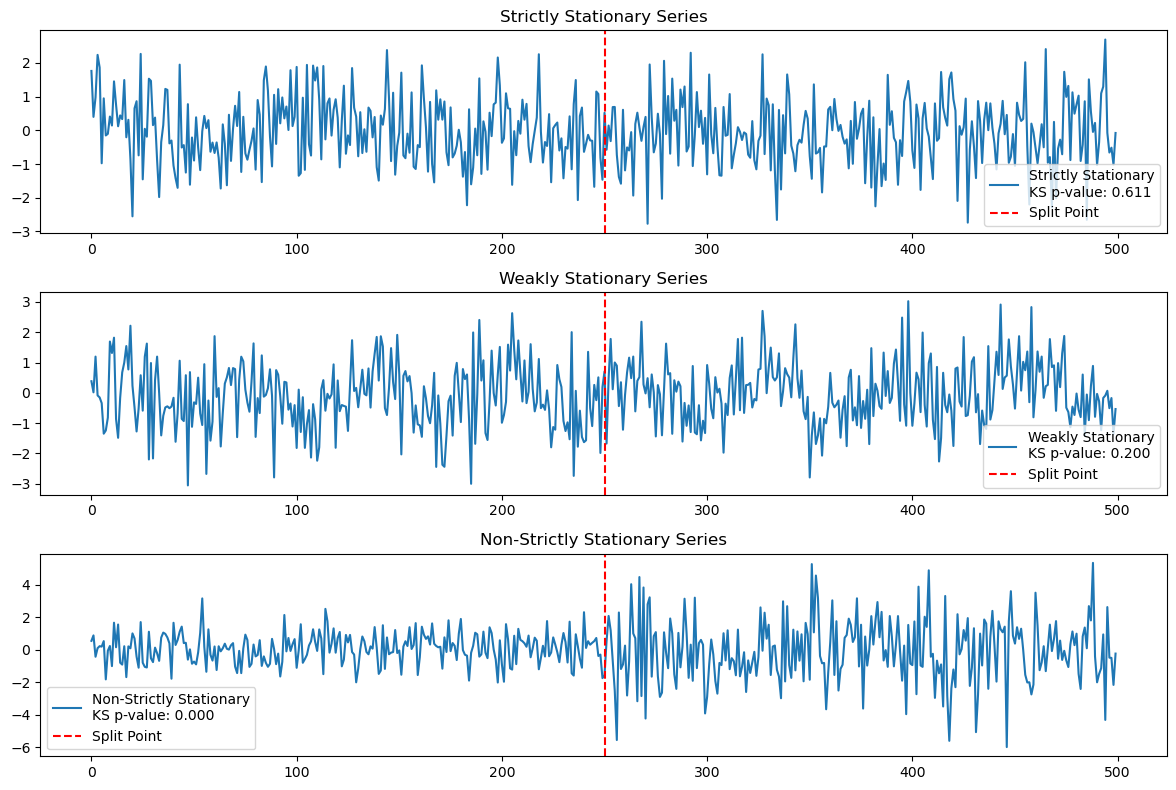

In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.stats import ks_2samp

# Generating synthetic data for demonstration 
np.random.seed(0)
n = 500

# Strictly stationary series: Normally distributed random noise 
strict_stationary_series = np.random.normal(0, 1, n)

# Weakly stationary series: Mean and variance constant, but non-random structure (e.g., AR process)
time = np.arange(n)
weak_stationary_series = 0.5 * np.sin(0.1 * time) + np.random.normal(0, 1, n)

# Non-strictly stationary series: Changing Variance 
non_strict_stationary_series = np.concatenate([
    np.random.normal(0, 1, n // 2),
    np.random.normal(0, 2, n // 2)  # Increased variance in the second half
])

# Function to split the series into two halves and perform the K-S test 
def ks_test_stationarity(series):
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Perform the K-S test on the series 
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(strict_stationary_series)
ks_stat_weak, ks_pvalue_weak = ks_test_stationarity(weak_stationary_series)
ks_stat_non_strict, ks_pvalue_non_strict = ks_test_stationarity(non_strict_stationary_series)

# Plotting the series 
plt.figure(figsize=(12, 8))

# Strictly stationary series
plt.subplot(3, 1, 1)
plt.plot(strict_stationary_series, label=f"Strictly Stationary\nKS p-value: {ks_pvalue_strict:.3f}")
plt.axvline(n // 2, color="red", linestyle="--", label="Split Point")
plt.title("Strictly Stationary Series")
plt.legend()

# Weakly stationary series
plt.subplot(3, 1, 2)
plt.plot(weak_stationary_series, label=f"Weakly Stationary\nKS p-value: {ks_pvalue_weak:.3f}")
plt.axvline(n // 2, color="red", linestyle="--", label="Split Point")
plt.title("Weakly Stationary Series")
plt.legend()

# Non-strictly stationary series
plt.subplot(3, 1, 3)
plt.plot(non_strict_stationary_series, label=f"Non-Strictly Stationary\nKS p-value: {ks_pvalue_non_strict:.3f}")
plt.axvline(n // 2, color="red", linestyle="--", label="Split Point")
plt.title("Non-Strictly Stationary Series")
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
import yfinance as yf
import numpy as np
from scipy.stats import ks_2samp

# Extract the 'Close' column and drop any missing values
close_prices = stock_data['Close'].squeeze()

# Split the data into two parts to perform the KS test (e.g., first half and second half)
n = len(close_prices)
halfway = n // 2
sample1 = close_prices[:halfway]
sample2 = close_prices[halfway:]

# Perform the KS test
ks_statistic, p_value = ks_2samp(sample1, sample2)

# Print the important metrics and hypotheses
print(f"KS Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Null and Alternative Hypothesis
print("\nNull Hypothesis (H₀): The two samples are from the same distribution (strictly stationary).")
print("Alternative Hypothesis (Hₐ): The two samples are from different distributions (not strictly stationary).")

# Decision based on p-value
if p_value > 0.05:
    print("\nFail to reject the null hypothesis: The data is likely strictly stationary.")
else:
    print("\nReject the null hypothesis: The data is likely not strictly stationary.")


KS Statistic: 0.9018569150148098
P-Value: 1.8561358368129563e-57

Null Hypothesis (H₀): The two samples are from the same distribution (strictly stationary).
Alternative Hypothesis (Hₐ): The two samples are from different distributions (not strictly stationary).

Reject the null hypothesis: The data is likely not strictly stationary.


# Snippit for K-S test 

In [9]:
import numpy as np 
import pandas as pd
from scipy.stats import ks_2samp

def ks_test_stationarity(series):
    """
    Perform the KS test to check stationarity.

    Parameters:
    series (array-like): Time series data to analyze.

    Returns:
    tuple: KS statistic and p-value
    """
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Load your data here (replace with your dataset and column)
# Example: df = pd.read_csv("your_dataset.csv")
data = {
    'time': np.arange(1000),
    'value': np.concatenate([
        np.random.normal(0, 1, 500), 
        np.random.normal(0, 2, 500)  # Simulating non-stationary behavior
    ])
}
df = pd.DataFrame(data)

# Specify the column to analyze
column_to_analyze = 'value'

# Perform the KS test
ks_stat, ks_pvalue = ks_test_stationarity(df[column_to_analyze])

# Output the results
print("KS Test Results:")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value: {ks_pvalue:.4f}")

# Interpret the results
alpha = 0.05  # Significance level
if ks_pvalue < alpha:
    print("\nConclusion: The series is likely non-stationary (reject null hypothesis).")
else:
    print("\nConclusion: The series is likely stationary (fail to reject null hypothesis).")


KS Test Results:
KS Statistic: 0.1840
p-value: 0.0000

Conclusion: The series is likely non-stationary (reject null hypothesis).
